Text(0.5, 1.0, '')

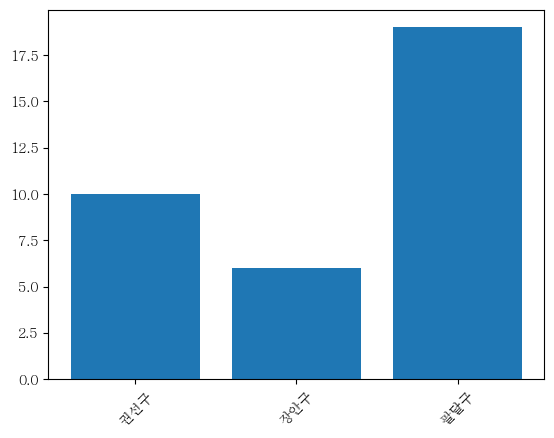

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fulldata_03_13_02_P_영화상영관.csv', encoding='cp949', low_memory=False)

# df.head(3)
# df.info()
# df.describe()
# df.shape
# df.columns
# print(df.columns.to_list())
# print(df.columns.values)
data_1 = df[['번호', '영업상태명', '사업장명', '소재지전체주소', '도로명전체주소']]
# data_1
data_1 = data_1.dropna(subset=['소재지전체주소'])
# data_1.info()
data_2 = data_1[ data_1['소재지전체주소'].str.contains('수원시') ]
# data_2.info()
# data_2.head()
data_3 = data_2[ data_2['사업장명'].str.contains('메가박스')]
# data_3.info()
# data_3

data_4 = data_3[data_3['영업상태명'] != '폐업']
# data_4.info()
# data_4
'경기도 수원시 팔달구 인계동 1125-1'.split()[2]
data_4.loc[:, '시군구'] = data_4['소재지전체주소'].str.split().str[2]
# data_4
data_5 = data_4.groupby('시군구').size().reset_index(name='사업장수')
# data_5

plt.rcParams['font.family'] = 'Batang'
plt.bar(
     data_5['시군구'],
     data_5['사업장수']
    )
plt.xticks(rotation=45)
plt.title('')
